# 4. Questões para Análise

### Importação de bibliotecas, leitura do arquivo CSV e criação do DataFrame


In [ ]:
#pip install pandas matplotlib seaborn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Importa o arquivo CSV e cria um data frame usando ele
df = pd.read_csv(r'C:\Users\Lily\Documents\VisualStudioCode\proj_5_pontos\State_of_data_BR_2023_Kaggle - df_survey_2023.csv', delimiter=',')


In [ ]:
# Renomeia as colunas do DataFrame para facilitar a manipulação do código
df = df.rename(columns={
    "('P1_b ', 'Genero')": "Genero",
    "('P1_a ', 'Idade')": "Idade",
    "('P1_l ', 'Nivel de Ensino')": "NivelDeEnsino",
    "('P1_i_2 ', 'Regiao onde mora')": "RegiaoOndeMora",
    "('P1_c ', 'Cor/raca/etnia')": "CorEtnia",
    "('P3_b_4 ', 'Cientista de Dados/Data Scientist')": "CientistaDados",
    "('P3_b_2 ', 'Engenharia de Dados/Data Engineer')": "EngenheiroDados",
    "('P3_b_3 ', 'Analista de Dados/Data Analyst')": "AnalistaDados"
})


In [ ]:
# Cria novo DataFrame com colunas relevantes
df_novo_1 = df[[
    "Genero",
    "Idade",
    "NivelDeEnsino",
    "RegiaoOndeMora",
    "CorEtnia",
    "CientistaDados",
    "EngenheiroDados",
    "AnalistaDados"
]].copy()

# Troca NaN por 0.0
df_novo_1[['CientistaDados', 'EngenheiroDados', 'AnalistaDados']] = \
    df_novo_1[['CientistaDados', 'EngenheiroDados', 'AnalistaDados']].fillna(0.0)

# Corrige valores ausentes
for col in ['Idade', 'CientistaDados', 'EngenheiroDados', 'AnalistaDados']:
    df_novo_1[col] = pd.to_numeric(df_novo_1[col], errors='coerce').fillna(0.0).astype(int)

# Cópias para outras análises
df_novo_2 = df_novo_1.copy()
df_novo_3 = df_novo_1.copy()

# Visualiza
df_novo_2.head(10)


,Genero,Idade,NivelDeEnsino,RegiaoOndeMora,CorEtnia,CientistaDados,EngenheiroDados,AnalistaDados
0,Masculino,31,Doutorado ou Phd,Sudeste,Branca,0,0,0
1,Masculino,30,Graduação/Bacharelado,Sudeste,Branca,0,0,0
2,Feminino,37,Graduação/Bacharelado,Sudeste,Amarela,0,0,0
3,Masculino,22,Estudante de Graduação,Sudeste,Preta,0,0,0
4,Masculino,34,Doutorado ou Phd,Sudeste,Branca,0,0,0
5,Masculino,30,Estudante de Graduação,Sudeste,Branca,0,0,0
6,Masculino,24,Graduação/Bacharelado,Sudeste,Branca,0,0,0
7,Masculino,35,Pós-graduação,Sudeste,Branca,0,1,0
8,Masculino,27,Graduação/Bacharelado,Sudeste,Parda,0,0,0
9,Masculino,28,Graduação/Bacharelado,Sudeste,Parda,0,0,0


## 4.1. Distribuição Etária por Profissão e Fatores Demográficos

### a) Por Gênero

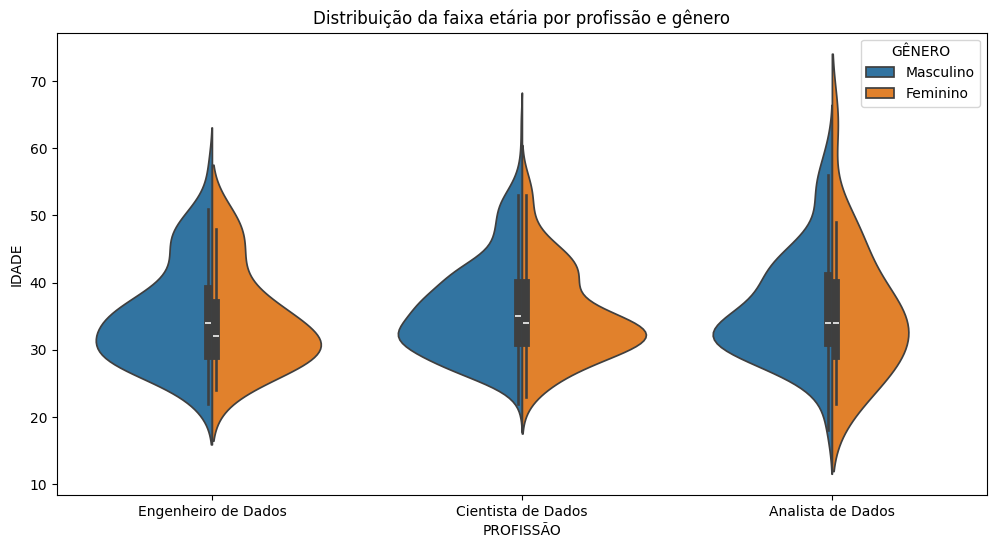

In [ ]:
# Cria uma função para identificar a profissão com base nas colunas binárias
def identificar_profissao(row):
    if row["CientistaDados"] == 1.0:
        return 'Cientista de Dados'
    elif row["EngenheiroDados"] == 1.0:
        return 'Engenheiro de Dados'
    elif row["AnalistaDados"] == 1.0:
        return 'Analista de Dados'
    else:
        return 'Nenhuma'

# Aplica a função à tabela e cria uma nova coluna com a profissão identificada
df_novo_1['profissao'] = df_novo_1.apply(identificar_profissao, axis=1)

# Remove linhas de pessoas que não atuam em nenhuma das profissões especificadas
df_novo_1 = df_novo_1[df_novo_1['profissao'] != 'Nenhuma']

# Remove linhas de pessoas que preferiram não informar seu gênero
df_novo_1 = df_novo_1[df_novo_1["Genero"] != "Prefiro não informar"]

# Cria um gráfico de violino para mostrar a distribuição da idade por profissão e gênero
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_novo_1,     # Dados a serem utilizados no gráfico
    x='profissao',      # Eixo X: profissão
    y='Idade',          # Eixo Y: idade
    hue='Genero',       # Cores separadas por gênero
    split=True          # Junta os gêneros em um único violino por profissão
)

# Define os rótulos e o título do gráfico
plt.title('Distribuição da faixa etária por profissão e gênero')
plt.xlabel('PROFISSÃO')
plt.ylabel('IDADE')
plt.legend(title='GÊNERO')

# Exibe o gráfico
plt.show()



Analistas de Dados:
- Maior tempo de atuação dos proficionais nessa área
- Menor retenção feminina na área. Invese propor soluções para almentar retenção.

Engenharia de Dados:
- Equilíbrio constante entre homens e mulheres, indicando melhor retenção e ambiente mais inclusivo para ambos os gêneros

### b) Por Etnia

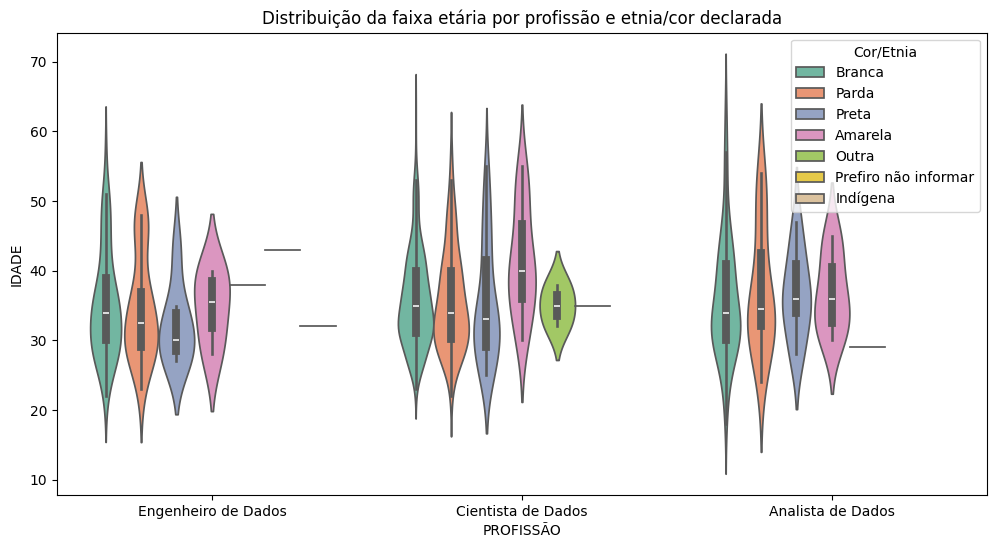

In [ ]:
# Cria uma função para identificar a profissão com base nas colunas binárias
def identificar_profissao(row):
    if row["CientistaDados"] == 1.0:
        return 'Cientista de Dados'
    elif row["EngenheiroDados"] == 1.0:
        return 'Engenheiro de Dados'
    elif row["AnalistaDados"] == 1.0:
        return 'Analista de Dados'
    else:
        return 'Nenhuma'

# Cria uma nova coluna com os valores retornados pela função identificar_profissao()
df_novo_2['profissao'] = df_novo_2.apply(identificar_profissao, axis=1)

# Remove pessoas que não atuam em nenhuma das profissões analisadas
df_novo_2 = df_novo_2[df_novo_2['profissao'] != 'Nenhuma']

# Cria o gráfico de violino com os dados filtrados
plt.figure(figsize=(12, 6))
sns.violinplot(
    # Utiliza os dados do DataFrame
    data=df_novo_2,
    # Define a profissão como eixo X
    x='profissao',
    # Define a idade como eixo Y
    y='Idade',
    # Agrupa os dados por cor/etnia declarada
    hue='CorEtnia',
    # Desativa a divisão do gráfico para manter um violino por grupo
    split=False,
    # Define a paleta de cores
    palette='Set2'
)

# Ajusta o título e rótulos do gráfico
plt.title('Distribuição da faixa etária por profissão e etnia/cor declarada')
plt.xlabel('PROFISSÃO')
plt.ylabel('IDADE')
plt.legend(title='Cor/Etnia')

# Exibe o gráfico
plt.show()


A presença de profissionais indígenas em Engenharia, Ciência e Análise de Dados é quase inexistente.
- Falta inclusão e são necessárias políticas de incentivo para essa população.

Outras etnias aparecem em número relevante apenas entre Cientistas de Dados.
- Pode haver fatores específicos, como programas de formação ou iniciativas voltadas à diversidade, concentrados na área de Ciência de Dados — o que ainda não se estende às demais profissões.

A maioria dos analistas de dados são brancos, nas três profissões analizadas.
- O setor ainda reflete desigualdades históricas de acesso e permanência.
